<a href="https://colab.research.google.com/github/anjuchakku22-web/reimagined-broccoli/blob/main/task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# style
sns.set(style="whitegrid")

In [2]:
# Load dataset (Seaborn built-in Titanic dataset)
df = sns.load_dataset('titanic')

# Preview data
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Check missing values
df.isnull().sum()

# Fill missing Age with median
df['age'].fillna(df['age'].median(), inplace=True)

# Fill Embarked with mode
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Drop Cabin (too many missing values)
df.drop(columns=['deck'], inplace=True)

# Confirm cleaning
df.isnull().sum()

/tmp/ipykernel_3329/1788714760.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_3329/1788714760.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [4]:
# Create Age Group
df['age_group'] = pd.cut(df['age'],
                        bins=[0, 12, 18, 35, 60, 100],
                        labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

# Family Size
df['family_size'] = df['sibsp'] + df['parch'] + 1

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,age_group,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,Young Adult,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Adult,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Young Adult,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Young Adult,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,Young Adult,1


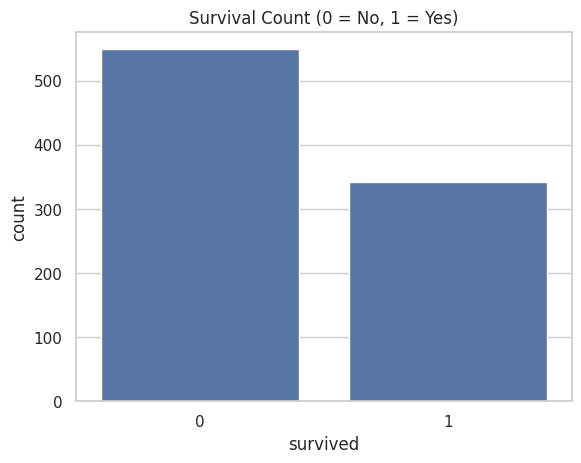

In [5]:
plt.figure()
sns.countplot(x='survived', data=df)
plt.title("Survival Count (0 = No, 1 = Yes)")
plt.show()

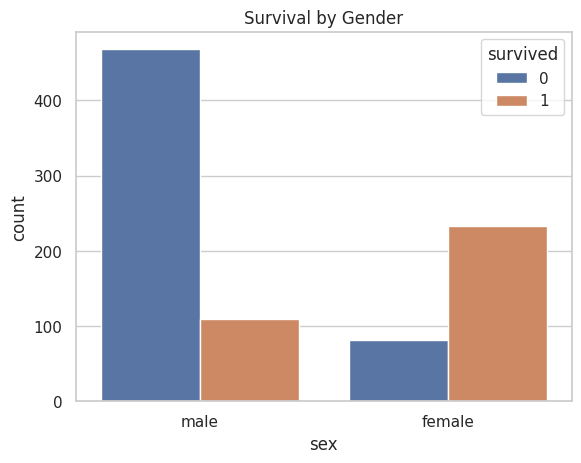

In [6]:
plt.figure()
sns.countplot(x='sex', hue='survived', data=df)
plt.title("Survival by Gender")
plt.show()

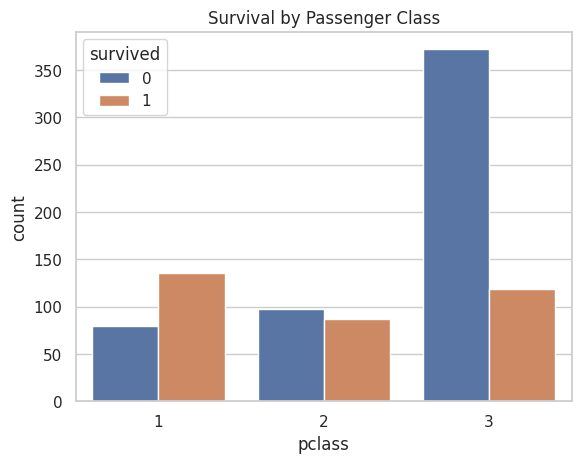

In [7]:
plt.figure()
sns.countplot(x='pclass', hue='survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

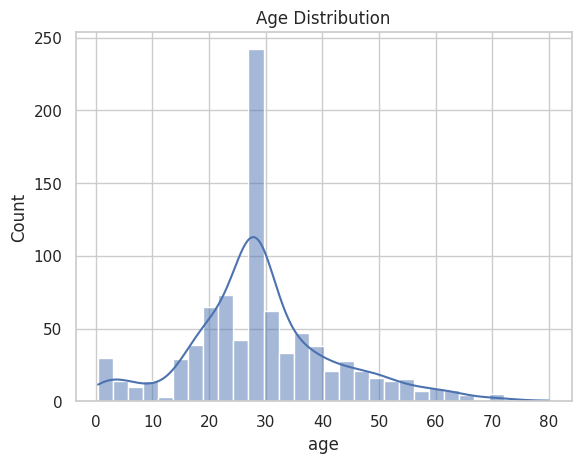

In [8]:
plt.figure()
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

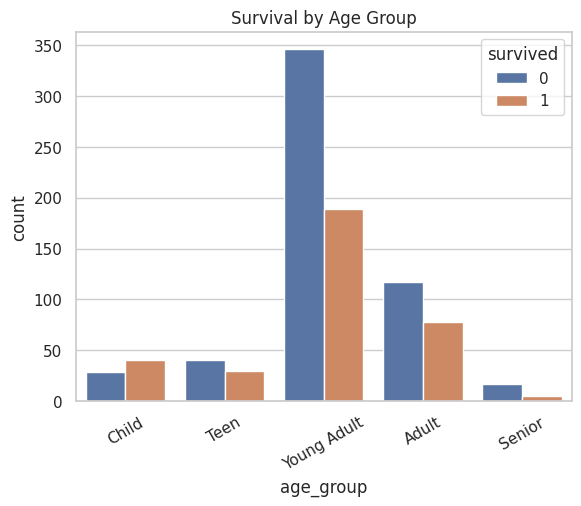

In [9]:
plt.figure()
sns.countplot(x='age_group', hue='survived', data=df)
plt.title("Survival by Age Group")
plt.xticks(rotation=30)
plt.show()

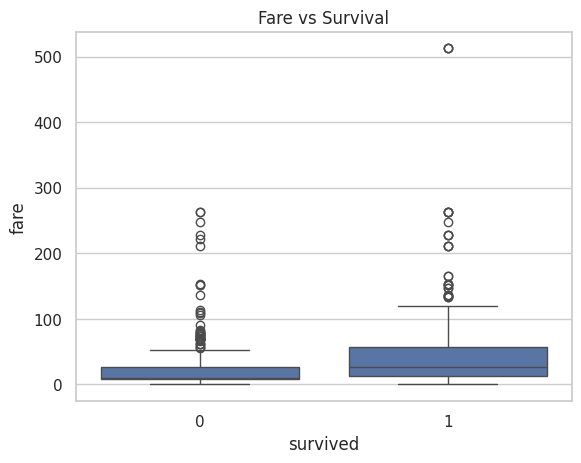

In [10]:
plt.figure()
sns.boxplot(x='survived', y='fare', data=df)
plt.title("Fare vs Survival")
plt.show()

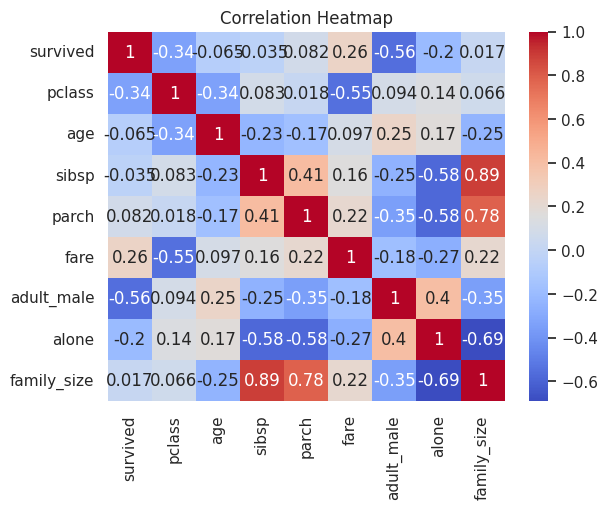

In [11]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

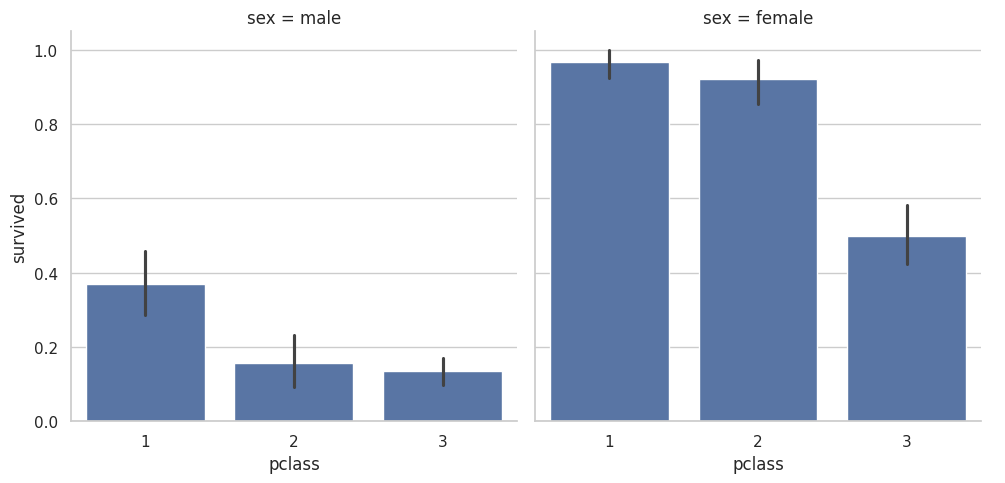

In [12]:
sns.catplot(x="pclass", y="survived", col="sex",
            kind="bar", data=df)

plt.show()